In [434]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import nltk.corpus

In [435]:
#Importing the dataset that will be used
df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv", encoding = 'latin1', header = None)

In [6]:
#Using header = none, because the first row is becoming as columns

In [436]:
df.head(10)

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [437]:
df.shape

(1600000, 6)

In [438]:
#Naming the columns since the header was none
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

In [439]:
#Checking if it has been applied
df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [440]:
#Checking if there are any missing values
df.isna().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [441]:
#Looking for existing duplicates
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1599995,False
1599996,False
1599997,False
1599998,False


In [442]:
df.describe()

,target,ids
count,1.600000e+06,1.600000e+06
mean,2.000000e+00,1.998818e+09
std,2.000001e+00,1.935761e+08
min,0.000000e+00,1.467810e+09
25%,0.000000e+00,1.956916e+09
50%,2.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [443]:
#Checking the columns that contain negative sentiment of text
df.query('target == 0')

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
799995,0,2329205009,Thu Jun 25 10:28:28 PDT 2009,NO_QUERY,dandykim,Sick Spending my day laying in bed listening ...
799996,0,2329205038,Thu Jun 25 10:28:28 PDT 2009,NO_QUERY,bigenya,Gmail is down?
799997,0,2329205473,Thu Jun 25 10:28:30 PDT 2009,NO_QUERY,LeeLHoke,rest in peace Farrah! So sad
799998,0,2329205574,Thu Jun 25 10:28:30 PDT 2009,NO_QUERY,davidlmulder,@Eric_Urbane Sounds like a rival is flagging y...


In [444]:
#Checking the columns that contain neutral sentiment of text
df.query('target == 2')

,target,ids,date,flag,user,text


In [445]:
#Checking the columns that contain positive sentiment of text
df.query('target == 4')

,target,ids,date,flag,user,text
800000,4,1467822272,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,ersle,I LOVE @Health4UandPets u guys r the best!!
800001,4,1467822273,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,becca210,im meeting up with one of my besties tonight! ...
800002,4,1467822283,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,Wingman29,"@DaRealSunisaKim Thanks for the Twitter add, S..."
800003,4,1467822287,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,katarinka,Being sick can be really cheap when it hurts t...
800004,4,1467822293,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,_EmilyYoung,@LovesBrooklyn2 he has that effect on everyone
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [17]:
#Replacing the positive values to 1 instead of 4 since there are no values in 2 (neutral)

In [446]:
df['target'] = df['target'].replace(4, 1)

In [447]:
df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


<ipython-input-448-01c94fe415f1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'target', data = df, palette = ['navy','orange'])


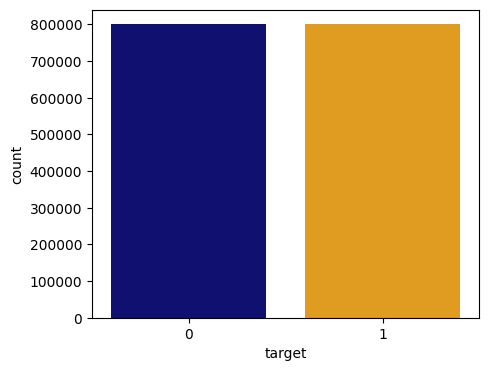

In [448]:
#Visualizing the two different sentiments (negative and positive)
plt.figure(figsize = (5,4))
sns.countplot(x = 'target', data = df, palette = ['navy','orange'])
plt.show()

In [449]:
#Checking the value count for 0 (Negative), and 1 (Positive)
df['target'].value_counts()

,count
target,
0,800000
1,800000


In [450]:
df['user'].nunique()

659775

In [451]:
#Overview of the texts in the text column
df['text'].head(20)

,text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,is upset that he can't update his Facebook by ...
2,@Kenichan I dived many times for the ball. Man...
3,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all...."
5,@Kwesidei not the whole crew
6,Need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...
8,@Tatiana_K nope they didn't have it
9,@twittera que me muera ?


## Preprocessing  of data

In [452]:
#Taking only a sample 0f 3% since 1.600.000 texts is a large amount of data which will take long time to process
df = df.sample(frac = 0.03)

In [453]:
df.head()

,target,ids,date,flag,user,text
512282,0,2190101910,Tue Jun 16 01:46:20 PDT 2009,NO_QUERY,christine_sc,@justinesc things i dont like about brisbane -...
531698,0,2196416883,Tue Jun 16 12:26:42 PDT 2009,NO_QUERY,Abraxas1337,just found out my masters project might be can...
318563,0,2002849107,Tue Jun 02 05:18:44 PDT 2009,NO_QUERY,tygerzoe,my heart goes out to all the families affected...
958318,1,1825689062,Sun May 17 06:32:25 PDT 2009,NO_QUERY,semilogical,@lilyroseallen with a camera of course
860997,1,1676538102,Fri May 01 22:20:56 PDT 2009,NO_QUERY,reginabeth,"Breaktime! Lunch is brown/red rice, fried milk..."


In [454]:
#Looking at the length of the sample dataset
print(len(df))

48000


In [455]:
#Removing unusable, useless, hashtags, link urls, tagged usernames, and special characters
import re

def remove_useless(text):
    text = re.sub(r'@\w+|https?://\s+|http\w+\s|#\w+|\d+|\(.*?!\)|[?+.\->]|[^a-zA-Z0-9\s]|(\w+)!',
                  '', text)
    return text

In [456]:
df['text'] = df['text'].apply(remove_useless)

In [457]:
#Convert words to remove uppercases, and only have lowercase
df['text'] = df['text'].str.lower()

In [458]:
df['text'].head(30)

,text
512282,things i dont like about brisbane helen yuck...
531698,just found out my masters project might be can...
318563,my heart goes out to all the families affected...
958318,with a camera of course
860997,lunch is brownred rice fried milkfish and cor...
566231,need a new basketball team to
1236776,crappy monday i need more and my mom says i ...
736401,dont want uni to start i dislike the timetable
346801,when the heck is new moon coming out im dyingg...
121621,wishing i was partying at the rodeo instead of...


### Tokenization

In [459]:
#Importing and downloading the needed library NLTK and module in order to tokenize the words in the text
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [460]:
# Tokenizing each text in the 'text' column
df['tkn_text'] = df['text'].apply(word_tokenize)

In [461]:
df.head(10)

,target,ids,date,flag,user,text,tkn_text
512282,0,2190101910,Tue Jun 16 01:46:20 PDT 2009,NO_QUERY,christine_sc,things i dont like about brisbane helen yuck...,"[things, i, dont, like, about, brisbane, helen..."
531698,0,2196416883,Tue Jun 16 12:26:42 PDT 2009,NO_QUERY,Abraxas1337,just found out my masters project might be can...,"[just, found, out, my, masters, project, might..."
318563,0,2002849107,Tue Jun 02 05:18:44 PDT 2009,NO_QUERY,tygerzoe,my heart goes out to all the families affected...,"[my, heart, goes, out, to, all, the, families,..."
958318,1,1825689062,Sun May 17 06:32:25 PDT 2009,NO_QUERY,semilogical,with a camera of course,"[with, a, camera, of, course]"
860997,1,1676538102,Fri May 01 22:20:56 PDT 2009,NO_QUERY,reginabeth,lunch is brownred rice fried milkfish and cor...,"[lunch, is, brownred, rice, fried, milkfish, a..."
566231,0,2206772401,Wed Jun 17 07:02:02 PDT 2009,NO_QUERY,andyroser24,need a new basketball team to,"[need, a, new, basketball, team, to]"
1236776,1,1992893513,Mon Jun 01 09:29:44 PDT 2009,NO_QUERY,audra_siemens,crappy monday i need more and my mom says i ...,"[crappy, monday, i, need, more, and, my, mom, ..."
736401,0,2265004279,Sun Jun 21 05:32:14 PDT 2009,NO_QUERY,babywei,dont want uni to start i dislike the timetable,"[dont, want, uni, to, start, i, dislike, the, ..."
346801,0,2016269592,Wed Jun 03 06:28:56 PDT 2009,NO_QUERY,samiboosie,when the heck is new moon coming out im dyingg...,"[when, the, heck, is, new, moon, coming, out, ..."
121621,0,1833551297,Sun May 17 23:39:16 PDT 2009,NO_QUERY,rosalynism,wishing i was partying at the rodeo instead of...,"[wishing, i, was, partying, at, the, rodeo, in..."


In [462]:
#Comparing the text before and after it has been tokenized
df[['text', 'tkn_text']]

,text,tkn_text
512282,things i dont like about brisbane helen yuck...,"[things, i, dont, like, about, brisbane, helen..."
531698,just found out my masters project might be can...,"[just, found, out, my, masters, project, might..."
318563,my heart goes out to all the families affected...,"[my, heart, goes, out, to, all, the, families,..."
958318,with a camera of course,"[with, a, camera, of, course]"
860997,lunch is brownred rice fried milkfish and cor...,"[lunch, is, brownred, rice, fried, milkfish, a..."
...,...,...
793987,im trying to find a way to get to,"[im, trying, to, find, a, way, to, get, to]"
1039790,stationary cabinet theres nary a site more ...,"[stationary, cabinet, theres, nary, a, site, m..."
283485,studying probably wont be back till thursday ...,"[studying, probably, wont, be, back, till, thu..."
1232087,in kinghorn now so pretty,"[in, kinghorn, now, so, pretty]"


In [36]:
#Dropping the text column in order to use the tokenized text column

In [463]:
df = df.drop(['text'], axis = 1)

### Stemming

In [464]:
#Importing the module in NLTK to stem the words
from nltk.stem import PorterStemmer

In [465]:
stmr = PorterStemmer()

In [466]:
#Using the PorterStemmer in order to stem the words e.g. enjoying to enjoy, eats to eat

In [467]:
df['stmr_text'] = [' '.join([stmr.stem(tkn) for tkn in text]) for text in df['tkn_text']]

In [468]:
df['stmr_text'].head(20)

,stmr_text
512282,thing i dont like about brisban helen yuck and...
531698,just found out my master project might be cancel
318563,my heart goe out to all the famili affect by a...
958318,with a camera of cours
860997,lunch is brownr rice fri milkfish and corn on ...
566231,need a new basketbal team to
1236776,crappi monday i need more and my mom say i nee...
736401,dont want uni to start i dislik the timet
346801,when the heck is new moon come out im dyinggggggg
121621,wish i wa parti at the rodeo instead of lie do...


### Stopwords

In [469]:
#Importing the module stopwords from NLTK library
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [470]:
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [471]:
#Adding the stopwords in a list
stopw_list = ['i', 'bb', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

In [472]:
#Adding other words to the list that is not in there yet
stopw_list += ['idk', 'to', 'dm', 'haha', 'hmm', 'ye', 'im']

In [473]:
df['cln_text'] = df['stmr_text'].apply(lambda text: ' '.join([tkn for tkn in text.split() if tkn not in stopw_list]))

In [474]:
df[['cln_text', 'stmr_text']]

,cln_text,stmr_text
512282,thing dont like brisban helen yuck home,thing i dont like about brisban helen yuck and...
531698,found master project might cancel,just found out my master project might be cancel
318563,heart goe famili affect air franc,my heart goe out to all the famili affect by a...
958318,camera cours,with a camera of cours
860997,lunch brownr rice fri milkfish corn side gosh ...,lunch is brownr rice fri milkfish and corn on ...
...,...,...
793987,tri find way get,im tri to find a way to get to
1039790,stationari cabinet nari site love mainlin shac...,stationari cabinet there nari a site more love...
283485,studi probabl wont back till thursday bye bye,studi probabl wont be back till thursday bye bye
1232087,kinghorn pretti,in kinghorn now so pretti


In [475]:
#Removing the tokenized text and stemmed text in order to have the cleaned text as the only remaining one
df = df.drop(['tkn_text', 'stmr_text'], axis = 1)

In [476]:
df

,target,ids,date,flag,user,cln_text
512282,0,2190101910,Tue Jun 16 01:46:20 PDT 2009,NO_QUERY,christine_sc,thing dont like brisban helen yuck home
531698,0,2196416883,Tue Jun 16 12:26:42 PDT 2009,NO_QUERY,Abraxas1337,found master project might cancel
318563,0,2002849107,Tue Jun 02 05:18:44 PDT 2009,NO_QUERY,tygerzoe,heart goe famili affect air franc
958318,1,1825689062,Sun May 17 06:32:25 PDT 2009,NO_QUERY,semilogical,camera cours
860997,1,1676538102,Fri May 01 22:20:56 PDT 2009,NO_QUERY,reginabeth,lunch brownr rice fri milkfish corn side gosh ...
...,...,...,...,...,...,...
793987,0,2326819554,Thu Jun 25 07:33:13 PDT 2009,NO_QUERY,Mirenny,tri find way get
1039790,1,1956861465,Thu May 28 22:52:49 PDT 2009,NO_QUERY,ellinoz,stationari cabinet nari site love mainlin shac...
283485,0,1992914237,Mon Jun 01 09:31:43 PDT 2009,NO_QUERY,Chara_S,studi probabl wont back till thursday bye bye
1232087,1,1991888097,Mon Jun 01 07:50:23 PDT 2009,NO_QUERY,emmaXIII,kinghorn pretti


In [478]:
#Making a copy of the dataset to use for the CNN model because of using the Bag of Words vectorizer for three models, which are KNN, Decision Tree, and Support Vector Machine,
#and using Tokenizer and pad sequences for the CNN model

In [477]:
df_CNN = df.copy()

In [479]:
df_CNN

,target,ids,date,flag,user,cln_text
512282,0,2190101910,Tue Jun 16 01:46:20 PDT 2009,NO_QUERY,christine_sc,thing dont like brisban helen yuck home
531698,0,2196416883,Tue Jun 16 12:26:42 PDT 2009,NO_QUERY,Abraxas1337,found master project might cancel
318563,0,2002849107,Tue Jun 02 05:18:44 PDT 2009,NO_QUERY,tygerzoe,heart goe famili affect air franc
958318,1,1825689062,Sun May 17 06:32:25 PDT 2009,NO_QUERY,semilogical,camera cours
860997,1,1676538102,Fri May 01 22:20:56 PDT 2009,NO_QUERY,reginabeth,lunch brownr rice fri milkfish corn side gosh ...
...,...,...,...,...,...,...
793987,0,2326819554,Thu Jun 25 07:33:13 PDT 2009,NO_QUERY,Mirenny,tri find way get
1039790,1,1956861465,Thu May 28 22:52:49 PDT 2009,NO_QUERY,ellinoz,stationari cabinet nari site love mainlin shac...
283485,0,1992914237,Mon Jun 01 09:31:43 PDT 2009,NO_QUERY,Chara_S,studi probabl wont back till thursday bye bye
1232087,1,1991888097,Mon Jun 01 07:50:23 PDT 2009,NO_QUERY,emmaXIII,kinghorn pretti


### Visualizing the targets

In [480]:
#Importing the WordCloud library to visualize the words within the text
from wordcloud import WordCloud

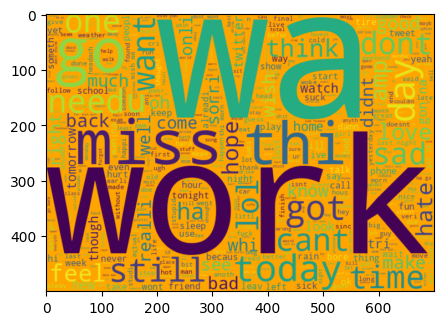

In [481]:
#Visualizing the negative expressions, and the possitive expressions
plt.figure(figsize = (5,4))
neg_text = ' '.join(df[df['target'] == 0]['cln_text'])
wcloud = WordCloud(max_words = 500, background_color = 'orange', width = 700, height = 500).generate(neg_text)
plt.imshow(wcloud, interpolation = 'bilinear')
plt.show()

In the visualization, negative expressions such as sad, hate, damn, left, bore, bad, suck, leave, and lost can be seen from the texts

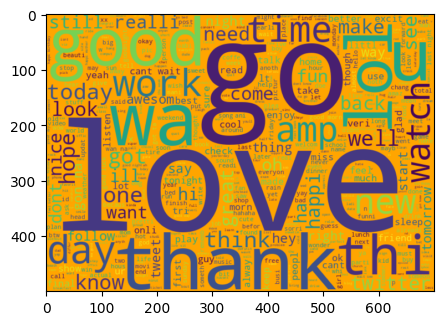

In [482]:
#Visualizing the postivie expressions
plt.figure(figsize = (5,4))
neg_text = ' '.join(df[df['target'] == 1]['cln_text'])
wcloud = WordCloud(max_words = 500, background_color = 'orange', width = 700, height = 500).generate(neg_text)
plt.imshow(wcloud, interpolation = 'bilinear')
plt.show()

In the visualization, positive expressions such as love, hope, well, awesome, friend, best, enjoy, great, and better can be seen from the texts

## Building a Bag of Words

In [483]:
#Importing the Bag of Words model CountVectorizer in order to transform the text
from sklearn.feature_extraction.text import CountVectorizer

In [484]:
vect = CountVectorizer()

In [485]:
X = vect.fit_transform(df['cln_text'])

In [486]:
y = df.iloc[:,0]

### Train/Test splitting the dataset for the models

In [487]:
from sklearn.model_selection import train_test_split

In [488]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 30)

In [489]:
X_train.shape

(38400, 32836)

In [490]:
X_test.shape

(9600, 32836)

In [491]:
y_train.shape

(38400,)

In [492]:
y_test.shape

(9600,)

## Training the models

In [65]:
#Importing necessary models for training

In [493]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

### KNN

In [494]:
knn = KNeighborsClassifier(n_neighbors = 10)

In [495]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [496]:
y_pred_KNN = knn.predict(X_test)

In [497]:
knn.score(X_test, y_test)

0.651875

### Decision Tree

In [498]:
dtr = DecisionTreeClassifier()

In [499]:
dtr.fit(X_train, y_train)

DecisionTreeClassifier()

In [500]:
y_pred_dtr = dtr.predict(X_test)

In [501]:
dtr.score(X_test, y_test)

0.6886458333333333

### Support Vector Machine

In [502]:
svcl = LinearSVC()

In [503]:
svcl.fit(X_train, y_train)

LinearSVC()

In [504]:
y_pred_svcl = svcl.predict(X_test)

In [505]:
svcl.score(X_test, y_test)

0.721875

## Evaluation of performance

In [506]:
#Importing metrics to evaluate models' scores
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [507]:
conmax_KNN = confusion_matrix(y_test, y_pred_KNN)

In [508]:
conmax_dtr = confusion_matrix(y_test, y_pred_dtr)

In [509]:
conmax_svcl = confusion_matrix(y_test, y_pred_svcl)

In [510]:
print(f'Confusion Matrix for KNN: \n {conmax_KNN}\n')
print(f'Confusion Matrix for Decision Tree: \n {conmax_dtr}\n')
print(f'Confusion Matrix for Support Vector Machine: \n {conmax_svcl}\n')

Confusion Matrix for KNN: 
 [[2731 2046]
 [1296 3527]]

Confusion Matrix for Decision Tree: 
 [[3404 1373]
 [1616 3207]]

Confusion Matrix for Support Vector Machine: 
 [[3367 1410]
 [1260 3563]]



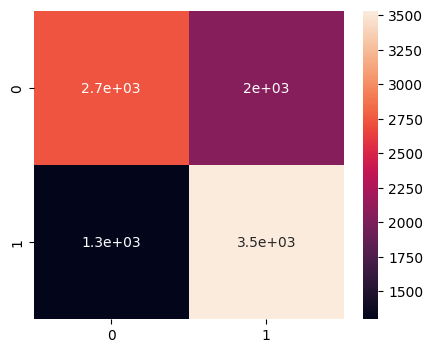

In [511]:
plt.figure(figsize = (5,4))
sns.heatmap(conmax_KNN, annot = True)
plt.show()

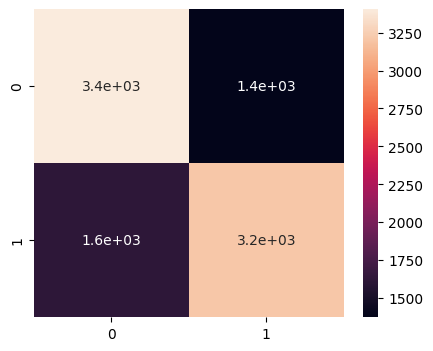

In [512]:
plt.figure(figsize = (5,4))
sns.heatmap(conmax_dtr, annot = True)
plt.show()

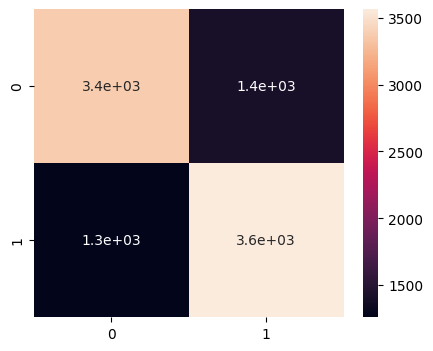

In [513]:
plt.figure(figsize = (5,4))
sns.heatmap(conmax_svcl, annot = True)
plt.show()

In [514]:
print(f'KNN Performance: \n {classification_report(y_test, y_pred_KNN)}')

KNN Performance: 
               precision    recall  f1-score   support

           0       0.68      0.57      0.62      4777
           1       0.63      0.73      0.68      4823

    accuracy                           0.65      9600
   macro avg       0.66      0.65      0.65      9600
weighted avg       0.66      0.65      0.65      9600



In [515]:
print(f'Decision Tree Performance: \n {classification_report(y_test, y_pred_dtr)}')

Decision Tree Performance: 
               precision    recall  f1-score   support

           0       0.68      0.71      0.69      4777
           1       0.70      0.66      0.68      4823

    accuracy                           0.69      9600
   macro avg       0.69      0.69      0.69      9600
weighted avg       0.69      0.69      0.69      9600



In [516]:
print(f'Support Vector Machine Performance: \n {classification_report(y_test, y_pred_svcl)}')

Support Vector Machine Performance: 
               precision    recall  f1-score   support

           0       0.73      0.70      0.72      4777
           1       0.72      0.74      0.73      4823

    accuracy                           0.72      9600
   macro avg       0.72      0.72      0.72      9600
weighted avg       0.72      0.72      0.72      9600



## Word embedding methods

In [517]:
#Importing the Word2Vec technique for embedding

In [337]:
from gensim.models import Word2Vec

In [91]:
import gensim.downloader as api

In [518]:
#Loading the Word2Vec technique

In [92]:
w2vec = api.load('word2vec-google-news-300')

In [519]:
#Importing tokenizer and pad sequences before applying the text to the Convolutional Neural Network, and train/test splitting the data for the CNN model

In [520]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [521]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [522]:
X_CNN = df_CNN['cln_text']
y_CNN = df_CNN['target']

In [523]:
#Specifying the size of vocabulary, converting the words, thereafter into sequences of a max length

In [524]:
vocab_size = 10000
tokenizer = Tokenizer(num_words = vocab_size)

In [525]:
tokenizer.fit_on_texts(X_CNN)

In [526]:
sequences = tokenizer.texts_to_sequences(X_CNN)


In [527]:
max_len = 50
X_pad = pad_sequences(sequences, maxlen = max_len, padding = 'post')

In [528]:
X_train_CNN, X_test_CNN, y_train_CNN, y_test_CNN = train_test_split(X_pad, y_CNN, train_size = 0.8)

### CNN model

In [529]:
#Importing necessary libaries/layers for the CNN model

In [530]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import GlobalMaxPooling1D
from tensorflow.keras.layers import Embedding

In [531]:
embedding_dim = 300

In [102]:
#Getting the model defined, and also building the model with  hidden layers and
#convolutional layers whereas dense layers receiving input from the neurons

In [532]:
cnn_seqmodel = Sequential()

In [533]:
#Adding layers and building the CNN model
cnn_seqmodel.add(Embedding(input_dim = vocab_size,
                           input_length = max_len,
                           output_dim = embedding_dim
                           ))
cnn_seqmodel.add(Conv1D(64, activation = 'relu', kernel_size = 3))
cnn_seqmodel.add(GlobalMaxPooling1D())
cnn_seqmodel.add(Dense(32, activation = 'relu'))
cnn_seqmodel.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [534]:
cnn_seqmodel.compile(
                    optimizer = 'adam',
                    loss = 'binary_crossentropy',
                    metrics = ['accuracy']
                    )

In [535]:
#Fitting the model for training
cnn_seqmodel.fit(X_train_CNN, y_train_CNN, batch_size = 32, epochs = 5)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.6917 - loss: 0.5714
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.8210 - loss: 0.3985
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 80s 48ms/step - accuracy: 0.8984 - loss: 0.2535
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - accuracy: 0.9457 - loss: 0.1395
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - accuracy: 0.9642 - loss: 0.0912


In [538]:
#Evaluating the model's performance
cnn_seqmodel.evaluate(X_test_CNN, y_test_CNN)

300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7208 - loss: 1.1351


[1.1569651365280151, 0.7160416841506958]

In [540]:
y_pred_CNN = cnn_seqmodel.predict(X_test_CNN)

300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


## Comparing results for CNN model with previous models

In [431]:
#Converting into labels that are binary while getting the threshold of 0.5 applied

In [541]:
y_pred_cnv_CNN = (y_pred_CNN > 0.5).astype(int)

In [543]:
#Comparing all models' results, now with CNN included
def view_values_accuracy():
    print(f'Accuracy score: ')
    print(f'KNN: {accuracy_score(y_test, y_pred_KNN)}')
    print(f'Decision Tree: {accuracy_score(y_test, y_pred_dtr)}')
    print(f'Support Vector Machine: {accuracy_score(y_test, y_pred_svcl)}')
    print(f'CNN: {accuracy_score(y_test_CNN, y_pred_cnv_CNN)}')

view_values_accuracy()

Accuracy score: 
KNN: 0.651875
Decision Tree: 0.6886458333333333
Support Vector Machine: 0.721875
CNN: 0.7160416666666667


In [ ]:
#Saving the model

In [433]:
cnn_seqmodel.save('text_model.h5')

# Conclusions

Through the results that have been provided, by looking at the accuraccy score of the four models, it can be concluded that the three machine learning models had a score between 0.65 to 0.72 with the Support Vector Machine having the highest score of 0.72, and KNN having the lowest of 0.65 with Decision Tree being in the middle with a score of 0.69. Even though Support vector Machine had a score of 0.72, the CNN model performed close with an accuracy score of 0.72, where only decimals differed, which can be concluded that the Support Vector Machine performed better than CNN. Things or actions for future suggestions that can be conducted in order to get the models to perform better are tasks such as using the GridSearchCV to adjust hyperparameters, or also try with RandomizedSearchCV. Other models could also be used such as Naive Bayes which is known for its effectivity when it comes to tasks related to text mining, or also XGBoost which have the possibility of handling relationships that are complex. Lastly, instead of CNN which are Convolutional Neural Networks, LSTM which are Long Short Term Memory Networks, can be used in order to see if that neural network can have a better performance than CNN.